# Build and plot radiometric spectral response curves

Paul Montesano, PhD  
Sept 2026

In [1]:
library(tidyverse)
library(patchwork)
library(RColorBrewer)
library(dplyr)

Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘stringr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ──────────────────────────────────────

In [2]:
#MAINDIR = '/explore/nobackup/projects/CSDA_eval/results/maxar/legion/geometric'

band_colors <- c(
  'Pan' = 'gray',
  'Coastal'  = '#4f3a89', 'Blue'     = '#1f78b4',
  'Green'    = '#33a02c', 'Green1'    = '#33a02c',
  'Yellow'   = '#ffd92f',
  'Red'      = '#e31a1c', 
  'RedEdge'  = '#b15928',
  'RedEdge1' = '#b15928',
  'RedEdge2' = '#b15928', #'#8b3a00', 
    'NIR' = 'indianred','NIR1'= 'indianred','NIR2'= 'indianred', #'#525252'
    'Cirrus'='steelblue','SWIR1'='steelblue','SWIR2'='steelblue',
    'Swir1'='steelblue','Swir2'='steelblue','Swir3'='steelblue','Swir4'='steelblue','Swir5'='steelblue','Swir6'='steelblue','Swir7'='steelblue','Swir8'='steelblue',
    'TIR1'='#B63679FF','TIR2'='#B63679FF'
)

band_order <- c('Pan','Coastal', 'Blue', 'Green', 'Green1', 'Yellow', 'Red',
                'RedEdge','RedEdge1', 'RedEdge2', 'NIR','NIR1','NIR2','Cirrus','SWIR1','SWIR2','Swir1','Swir2','Swir3','Swir4','Swir5','Swir6','Swir7','Swir8','TIR1','TIR2'
)

sat_colors <- c(
  'LG01' = '#1b9e77', 'LG02' = '#d95f02', 'LG03' = '#7570b3',
  'LG04' = '#e7298a', 'LG05' = '#66a61e', 'LG06' = '#e6ab02',
  'LG07' = '#a6761d', 'LG08' = '#666666', 'LG09' = '#1f78b4'
)

In [3]:
# options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 150)

# library(viridisLite)
# library(scales)

# # Generate and display 12 colors from the magma palette
# show_col(magma(5))
# magma(5)

In [4]:
# Define the root search path
DIR_EVAL_RESULTS_DB="/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db"
DIR_RSR_RESULTS <- paste0(DIR_EVAL_RESULTS_DB, "/rsr")
CSDA_RSR_CURVE_DATA_FN = paste0(DIR_RSR_RESULTS,'/','csda_rsr_curve_data.csv') 

### RSR Curves

### Load a variety of RSR files

In [21]:
rsr_files = list.files(
    path = DIR_RSR_RESULTS,
    pattern = "RSR.*\\.csv$",
    recursive = TRUE,
    full.names = TRUE
)

df_rsr <- rsr_files %>%
  set_names() %>%
  #map_df(read_csv, .id = "source_file") %>%
  map_df(read_csv, show_col_types = FALSE, .id = "source_file")  %>%
  mutate(
    affiliation = case_when(
      str_detect(sensor, "^LG0")    ~ "Vantor",
      str_detect(sensor, "^newsat") ~ "Satellogic",
      str_detect(sensor, "^PHR1|^PNEO|^SPOT") ~ "Airbus",
      str_detect(sensor, "^BS")     ~ "BlackSky",
      .default = NA_character_
    ),
    constellation = case_when(
      str_detect(sensor, "^LG0")    ~ "Legion",
      str_detect(sensor, "^newsat") ~ "NewSat (Aleph-1)",#"Aleph-1",
      str_detect(sensor, "^PHR1")   ~ "Pleiades",
      str_detect(sensor, "^PNEO")   ~ "PleiadesNeo",
      str_detect(sensor, "^SPOT")   ~ "SPOT",
      str_detect(sensor, "^BS")     ~ "Global",
      .default = NA_character_
    ),
    band = as.character(band),
    band = case_when(
      str_detect(band, "Coastal")   ~ "Coastal",
      str_detect(band, "Red_Edge")  ~ "RedEdge",
      .default = band
    ),
    band   = factor(band, levels = band_order),
    sensor = factor(sensor)
  ) %>%
  select(-source_file, everything(), source_file) %>%
  droplevels()
dim(df_rsr)

[1] 153106     16

In [6]:
table(df_rsr$affiliation)


    Airbus   BlackSky Satellogic     Vantor 
     18714       2103      79823       9726 

In [7]:
table(df_rsr$sensor)


     BS0      BS1     LG01     LG02     LG03     LG04     LG05     LG06 
    1051     1052     1902     1182     2146     2140     1171     1185 
  MSI 2C newsat06 newsat07 newsat08 newsat09 newsat10 newsat11 newsat12 
   29913     1722     1722     1990     1990     1982     1893     2013 
newsat13 newsat14 newsat15 newsat16 newsat17 newsat18 newsat19 newsat20 
    2046     1722     1990     1974     1953     1953     2201     2182 
newsat21 newsat22 newsat23 newsat24 newsat25 newsat26 newsat27 newsat28 
    2057     1953     2132     2144     2083     2114     2144     2144 
newsat29 newsat30 newsat31 newsat32 newsat33 newsat34 newsat36 newsat37 
    2144     2144     2144     2144     2144     2144     2002     1982 
newsat40 newsat41 newsat43 newsat44 newsat46 newsat48 newsat49 newsat50 
    2144     2144     2144     2202     2050     2003     2180     2004 
   OLI-1    OLI-2    PHR1A    PHR1B    PNEO3    PNEO4    SPOT6    SPOT7 
    1242     1143     1045     1145     5257     5

### Load and integrate MAXAR legacy RSR Data

The MAXAR legacy RSR files have different headers and wavelength units in nm. The code below reads them all.

In [22]:
source('../lib/evallib.r')  # custom maxar read function

In [23]:
# Read all MAXAR legacy RSR files
maxar_dir <- paste0(DIR_EVAL_RESULTS_DB, "/rsr/commercial/maxar")
maxar_legacy_files <- list.files(
  path       = maxar_dir,
  pattern    = "^BandPass.*\\.txt$",
  recursive  = TRUE,
  full.names = TRUE
)

df_rsr_maxar_legacy <- maxar_legacy_files %>%
  set_names() %>%
  map_df(read_maxar_legacy_rsr, .id = "source_file")
dim(df_rsr_maxar_legacy)

[1] 47836     7

### Load and integrate Planet RSR Data

The Planet RSR files have different header names and wavelength units. The code below reads them all, normalizes the columns, and combines with the existing df_rsr dataframe.

In [24]:
source('../lib/evallib.r') # custom planet read function

In [25]:
# Read all Planet RSR files
planet_dir <- paste0(DIR_EVAL_RESULTS_DB, "/rsr/commercial/planet")
planet_files <- list.files(planet_dir, pattern = "\\.csv$", full.names = TRUE)

# Use safely to handle any files that might fail to read
df_planet_rsr <- planet_files %>%
  set_names() %>%
  map_df(safely(read_planet_rsr), .id = "source_file") %>%
  #filter(!is.na(result)) %>%
  unnest(result) %>%
  #select(-error) %>%
  mutate(sensor = factor(sensor)) %>%
  droplevels()
dim(df_planet_rsr)

[1] 58310     7

### Load Landsat and Sentinel-2 RSRs

In [26]:
# Read all civil RSR files
civil_dir <- paste0(DIR_EVAL_RESULTS_DB, "/rsr/civil")
civil_files <- list.files(civil_dir, pattern = "\\.csv$", full.names = TRUE)

# Use safely to handle any files that might fail to read
df_rsr_civil <- civil_files %>%
  set_names() %>%
  map_df(read_csv, .id = "source_file", show_col_types = FALSE) %>%
  mutate(sensor = factor(sensor)) %>%
  select(-source_file, everything(), source_file) %>%
  droplevels()
dim(df_rsr_civil)

[1] 32481     7

In [27]:
head(df_rsr_civil)

wavelength_nm,rsr,band,sensor,affiliation,constellation,source_file
<dbl>,<dbl>,<chr>,<fct>,<chr>,<chr>,<chr>
427,0.00036798,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
428,0.00072189,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
429,0.00205797,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
430,0.00360595,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
431,0.00877048,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv
432,0.02224460,Coastal Blue,OLI-2,NASA/USGS,Landsat,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/landsat_89_RSR.csv


### Combine all RSR data frames

In [28]:
# Combine with existing df_rsr
df_rsr_commercial <- bind_rows(
      df_rsr_maxar_legacy %>%
        mutate(
          band = as.character(band),
          sensor = as.character(sensor)
        ),
      df_rsr %>%
        mutate(
          band = as.character(band),
          sensor = as.character(sensor)
        ),
      df_planet_rsr 
     ) %>%
     select(wavelength_nm, rsr, sensor, band, affiliation, constellation, source_file) %>%
    mutate(sector = 'Commercial')

 df_rsr_civil = df_rsr_civil %>%
    mutate(
      band = as.character(band),
      sensor = as.character(sensor),
      sector = 'Civil'  
    )

df_rsr_combined = bind_rows(df_rsr_commercial, df_rsr_civil) %>%
  mutate(
    # Standardize band names across all sources
    band = case_when(
      str_detect(band, 'Coastal|Coastal-Blue') ~ 'Coastal',
      #   str_detect(band, 'Green') ~ 'Green',
      # str_detect(band, 'Red.?[Ee]dge|RedEdge') ~ 'RedEdge',
      #   str_detect(band, 'NIR') ~ 'NIR',
      #   str_detect(band, 'SWIR') ~ 'SWIR',
      TRUE ~ band
    ),
    band = factor(band, levels = band_order),
    sensor = factor(sensor)
  ) %>%
  select(-source_file, everything(), source_file) %>%
  #select(!c('Wavelength [µm]','Blue','Green','Red','NIR','WL [µm]','Wavelength [um]','Red Edge','Pan')) %>% 
  droplevels() %>% drop_na()


#cat("Loaded", nrow(df_planet_rsr), "rows from", length(planet_files), "Planet RSR files\n")
cat("Total rows in combined df_rsr:", nrow(df_rsr_combined), "\n")

# Diagnostic: Check what's in df_rsr after combining
cat("Unique affiliations in df_rsr:\n")
print(table(df_rsr_combined$affiliation))
cat("\n")
cat("Unique constellations in df_rsr:\n")
print(table(df_rsr_combined$constellation))
cat("\n")

Total rows in combined df_rsr: 244391 
Unique affiliations in df_rsr:

    Airbus   BlackSky        ESA      Maxar  NASA/USGS     Planet Satellogic 
     18714       2103      25311      47836       2568      58310      79823 
    Vantor 
      9726 

Unique constellations in df_rsr:

    Dove-Classic           Dove-R           GeoEye           Global 
             788             2404             3755             2103 
         Landsat           Legion NewSat (Aleph-1)         Pleiades 
            2568             9726            79823             2190 
     PleiadesNeo        QuickBird         RapidEye       Sentinel-2 
           10514              755             5005            25311 
          SkySat             SPOT        SuperDove              WV2 
           45305             6010             4808             6759 
             WV3 
           36567 



In [29]:
tail(df_rsr_combined)

wavelength_nm,rsr,sensor,band,affiliation,constellation,sector,source_file
<dbl>,<dbl>,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>
2595,0,MSI 2C,SWIR2,ESA,Sentinel-2,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2596,0,MSI 2C,SWIR2,ESA,Sentinel-2,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2597,0,MSI 2C,SWIR2,ESA,Sentinel-2,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2598,0,MSI 2C,SWIR2,ESA,Sentinel-2,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2599,0,MSI 2C,SWIR2,ESA,Sentinel-2,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv
2600,0,MSI 2C,SWIR2,ESA,Sentinel-2,Civil,/explore/nobackup/projects/CSDA_eval/results/evaluation_results_db/rsr/civil/sentinel2_abc_RSR.csv


## Write RSR dB

In [30]:
write_csv(df_rsr_combined, CSDA_RSR_CURVE_DATA_FN)

## Plot RSR dB

In [17]:
PLOT_RSR_CURVES <- function(df_rsr_combined) {
  
  # ── Collapsed legend label lookup ─────────────────────────────────────────────
  collapse_band <- function(b) {
    case_when(
      str_detect(b, "(?i)swir")    ~ "SWIR",
      str_detect(b, "(?i)rededge") ~ "RedEdge",
      str_detect(b, "(?i)^nir")    ~ "NIR",
      str_detect(b, "(?i)^tir")    ~ "TIR",
      TRUE                         ~ b
    )
  }
  
  # ── Derive legend_band levels from band_order (collapse groups, keep order) ───
  legend_band_levels <- band_order %>%
    collapse_band() %>%
    unique()   # preserves order of first appearance in band_order
  
  # ── Create plot data - original data untouched ────────────────────────────────
  plot_data <- df_rsr_combined %>%
    drop_na() %>%
    filter(rsr != 0) %>%
    mutate(
      legend_band = factor(
        collapse_band(as.character(band)),
        levels = legend_band_levels
      )
    )
  
  # ── Helper to grab first matching color from band_colors ─────────────────────
  first_match_col <- function(pattern) {
    unname(band_colors[str_detect(names(band_colors), pattern)][1])
  }
  
  # ── Build legend color vector - drop sub-bands, add one entry per group ───────
  legend_band_colors <- c(
    band_colors[!str_detect(names(band_colors), "(?i)swir|rededge|^nir|^tir")],
    "NIR"     = first_match_col("(?i)^nir"),
    "RedEdge" = first_match_col("(?i)rededge"),
    "SWIR"    = first_match_col("(?i)swir"),
    "TIR"     = first_match_col("(?i)^tir")
  )
  
  # ── Plot ──────────────────────────────────────────────────────────────────────
  rsr_plot <- ggplot(
    plot_data,
    aes(
      x     = wavelength_nm,
      y     = rsr,
      color = legend_band,
      fill  = legend_band,
      group = interaction(sensor, band)   # keeps all sub-bands plotted separately
    )
  ) +
    geom_area(position = "identity", alpha = 0.1, color = NA) +
    geom_line(linewidth = 0.2, alpha = 0.9) +
    coord_cartesian(ylim = c(0.25, 1)) +
    scale_color_manual(values = legend_band_colors, name = "Spectral Band") +
    scale_fill_manual(values  = legend_band_colors, name = "Spectral Band") +
    labs(
      title = "Spaceborne Optical Image Relative Spectral Response Curves",
      x     = "Wavelength (nm)",
      y     = "Relative Spectral Response"
    ) +
    theme_bw(base_size = 11) +
    theme(
      strip.text.y     = element_text(face = "bold", size = 6, angle = -90),
      panel.grid.minor = element_blank(),
      legend.position  = "right",
      legend.title     = element_text(face = "bold"),
      plot.title       = element_text(face = "bold", size = 13)
    ) +
    facet_grid(sector + affiliation + constellation ~ .) +
    guides(fill = guide_legend(override.aes = list(alpha = 1)))
  
  print(rsr_plot)
}

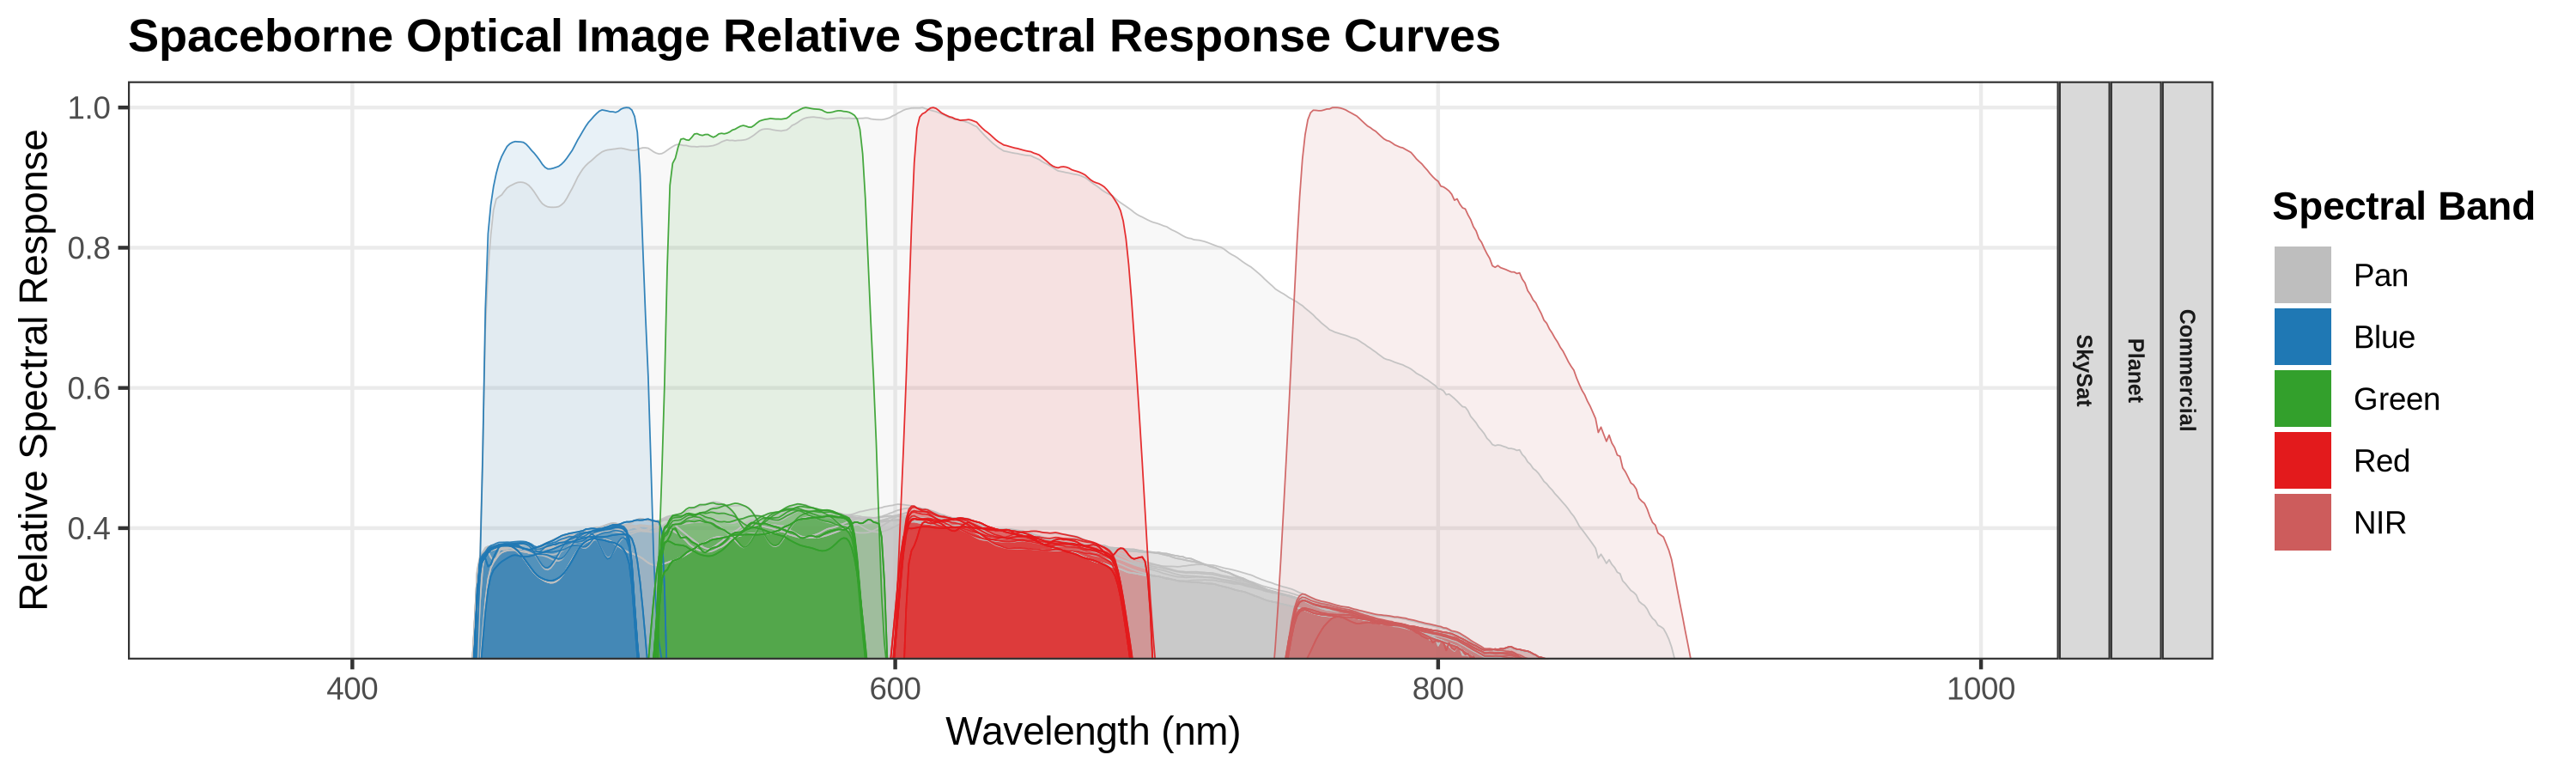

In [18]:
options(repr.plot.width = 10, repr.plot.height = 3, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(constellation == 'SkySat'))

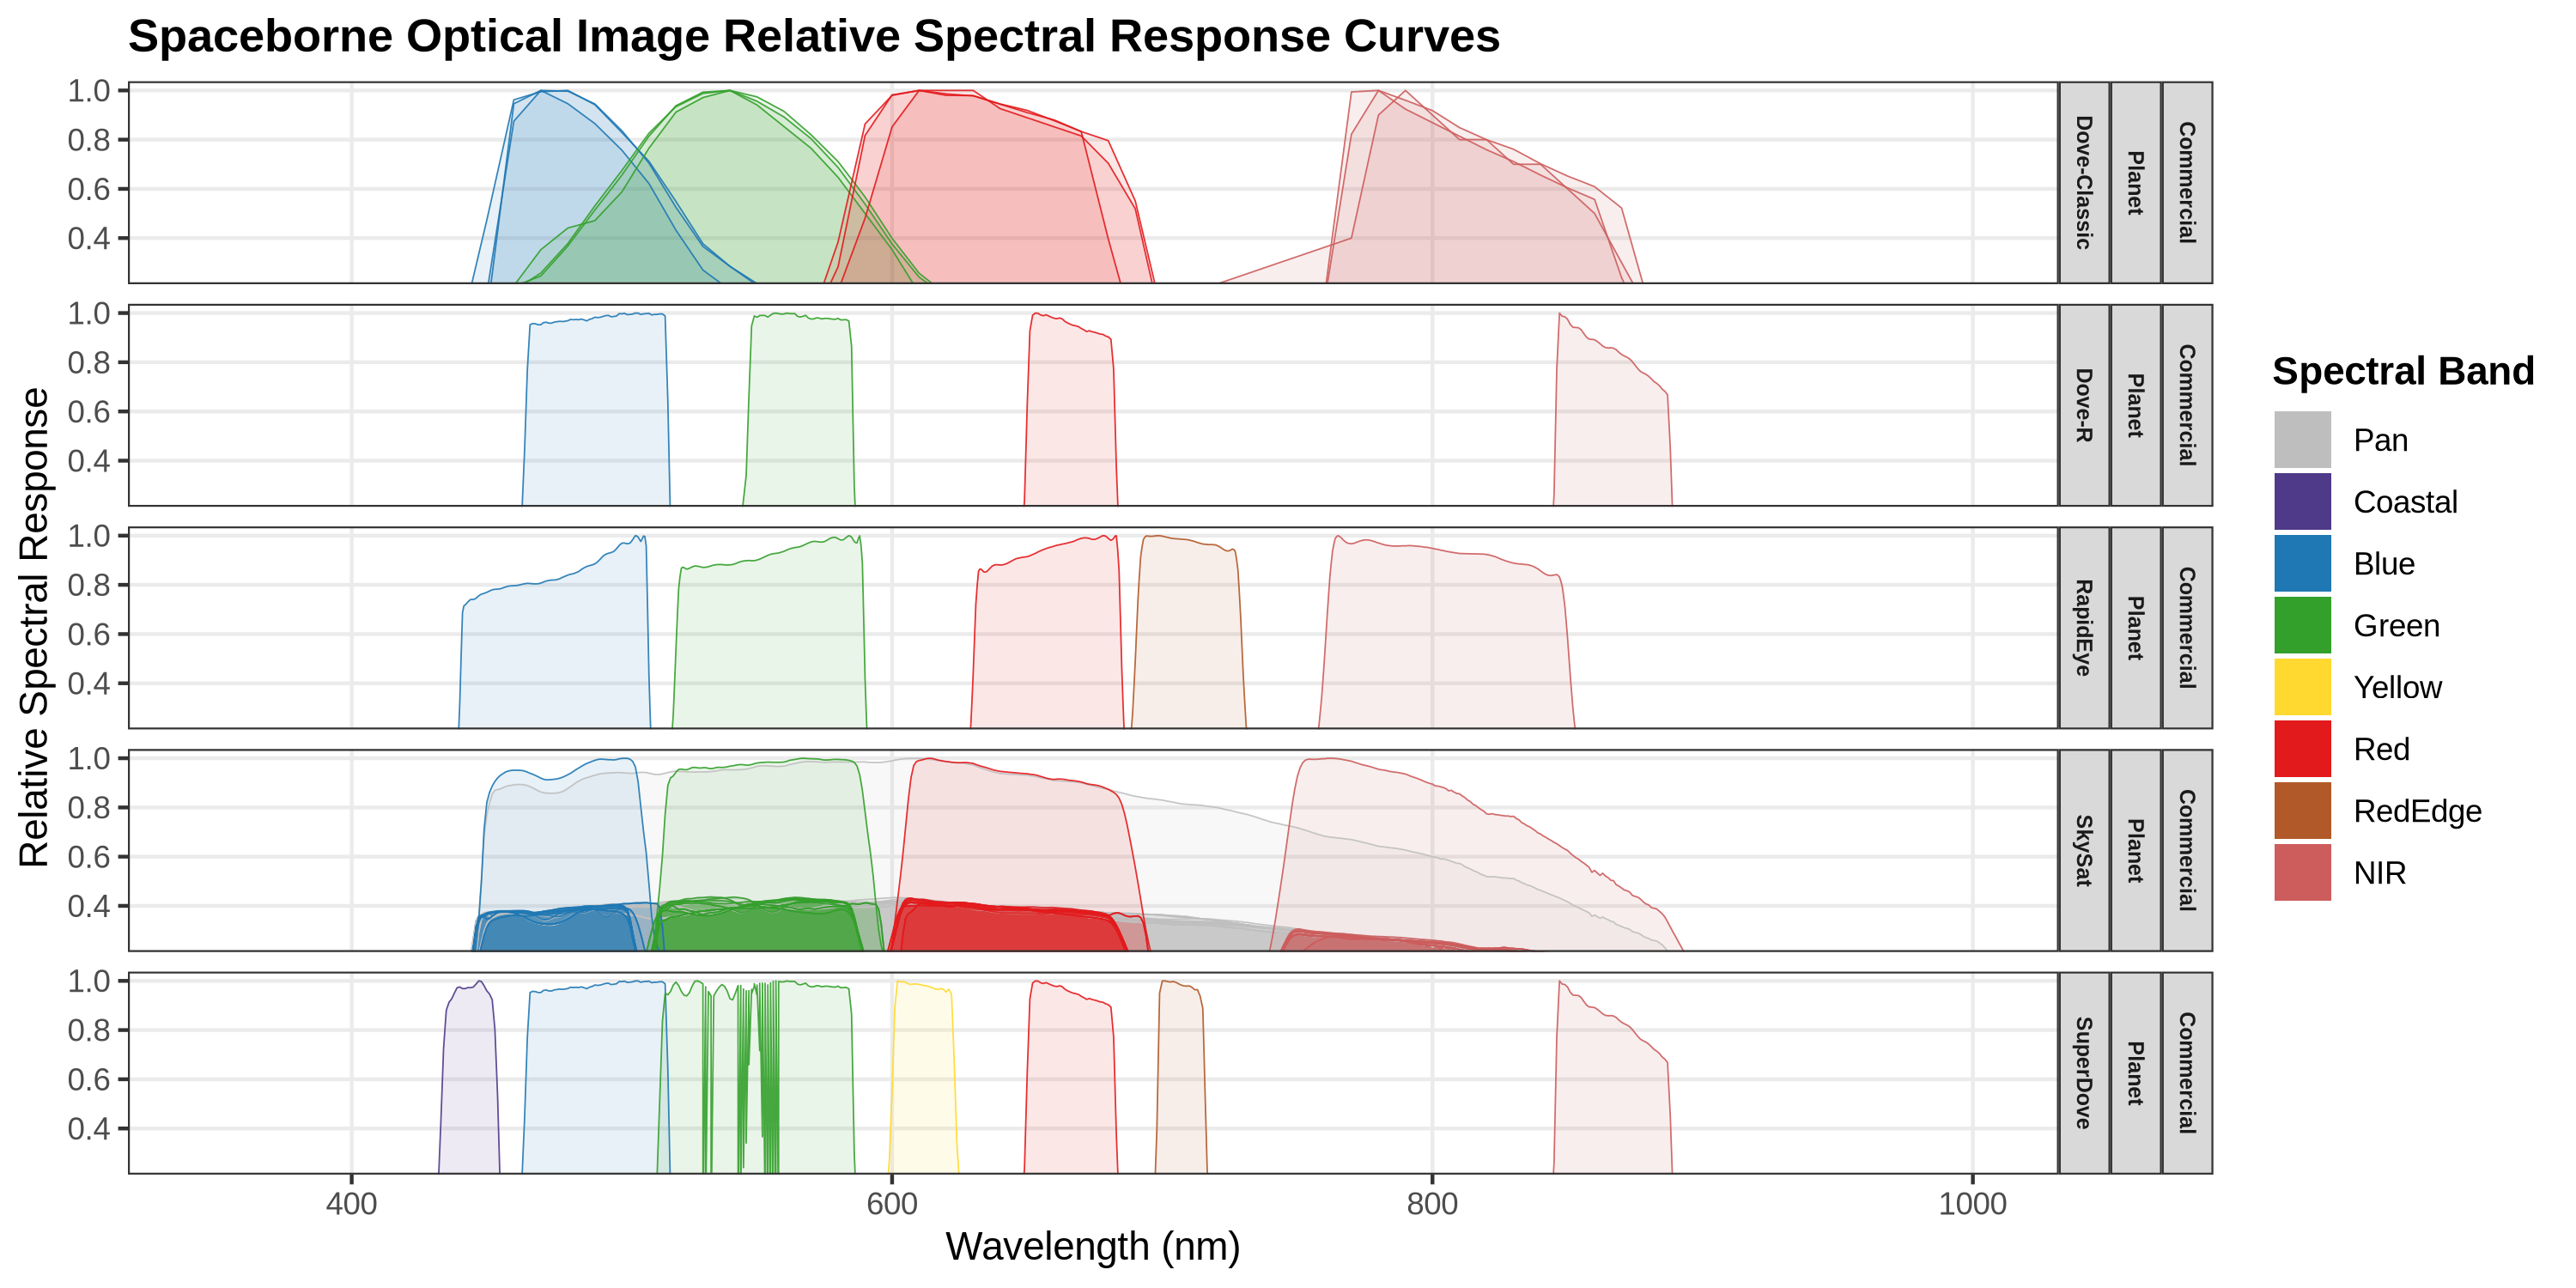

In [19]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(affiliation == 'Planet'))

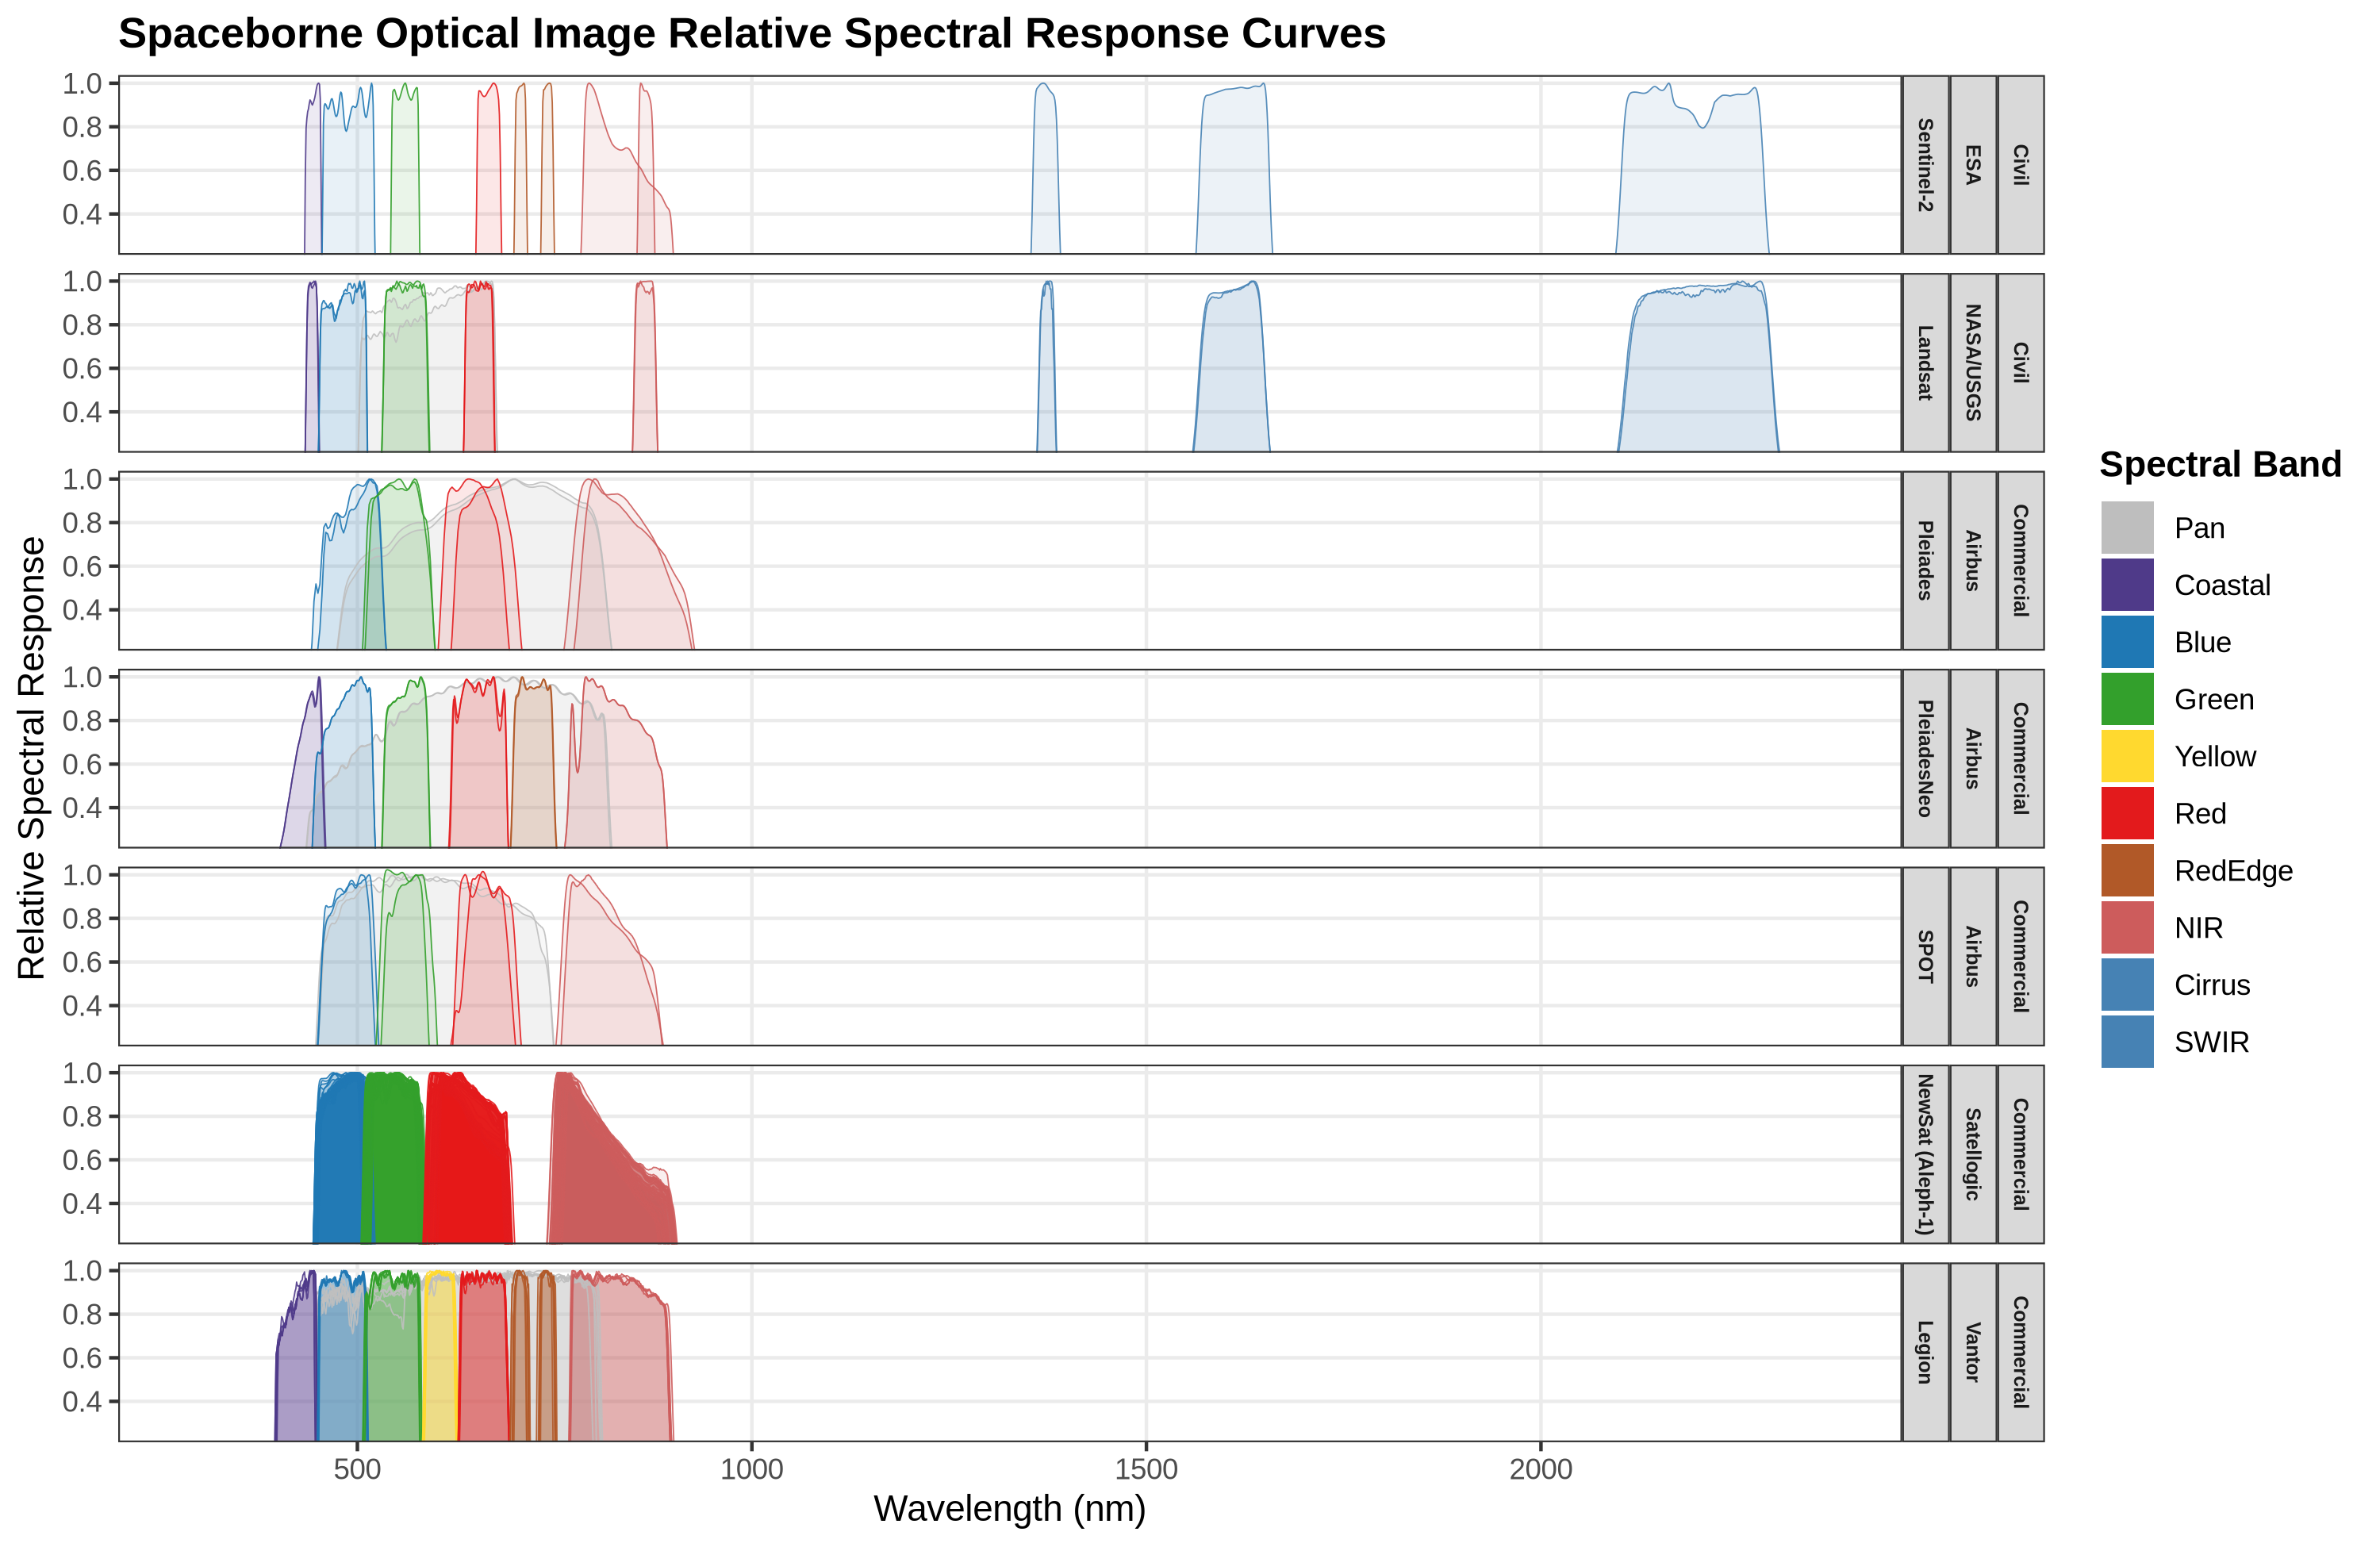

In [33]:
options(repr.plot.width = 10, repr.plot.height = 6.5, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(constellation %in% c("NewSat (Aleph-1)","Pleiades","PleiadesNeo","SPOT", "Legion", "Sentinel-2", "Landsat")) %>% filter(!(band %in% c('TIR1','TIR2'))))

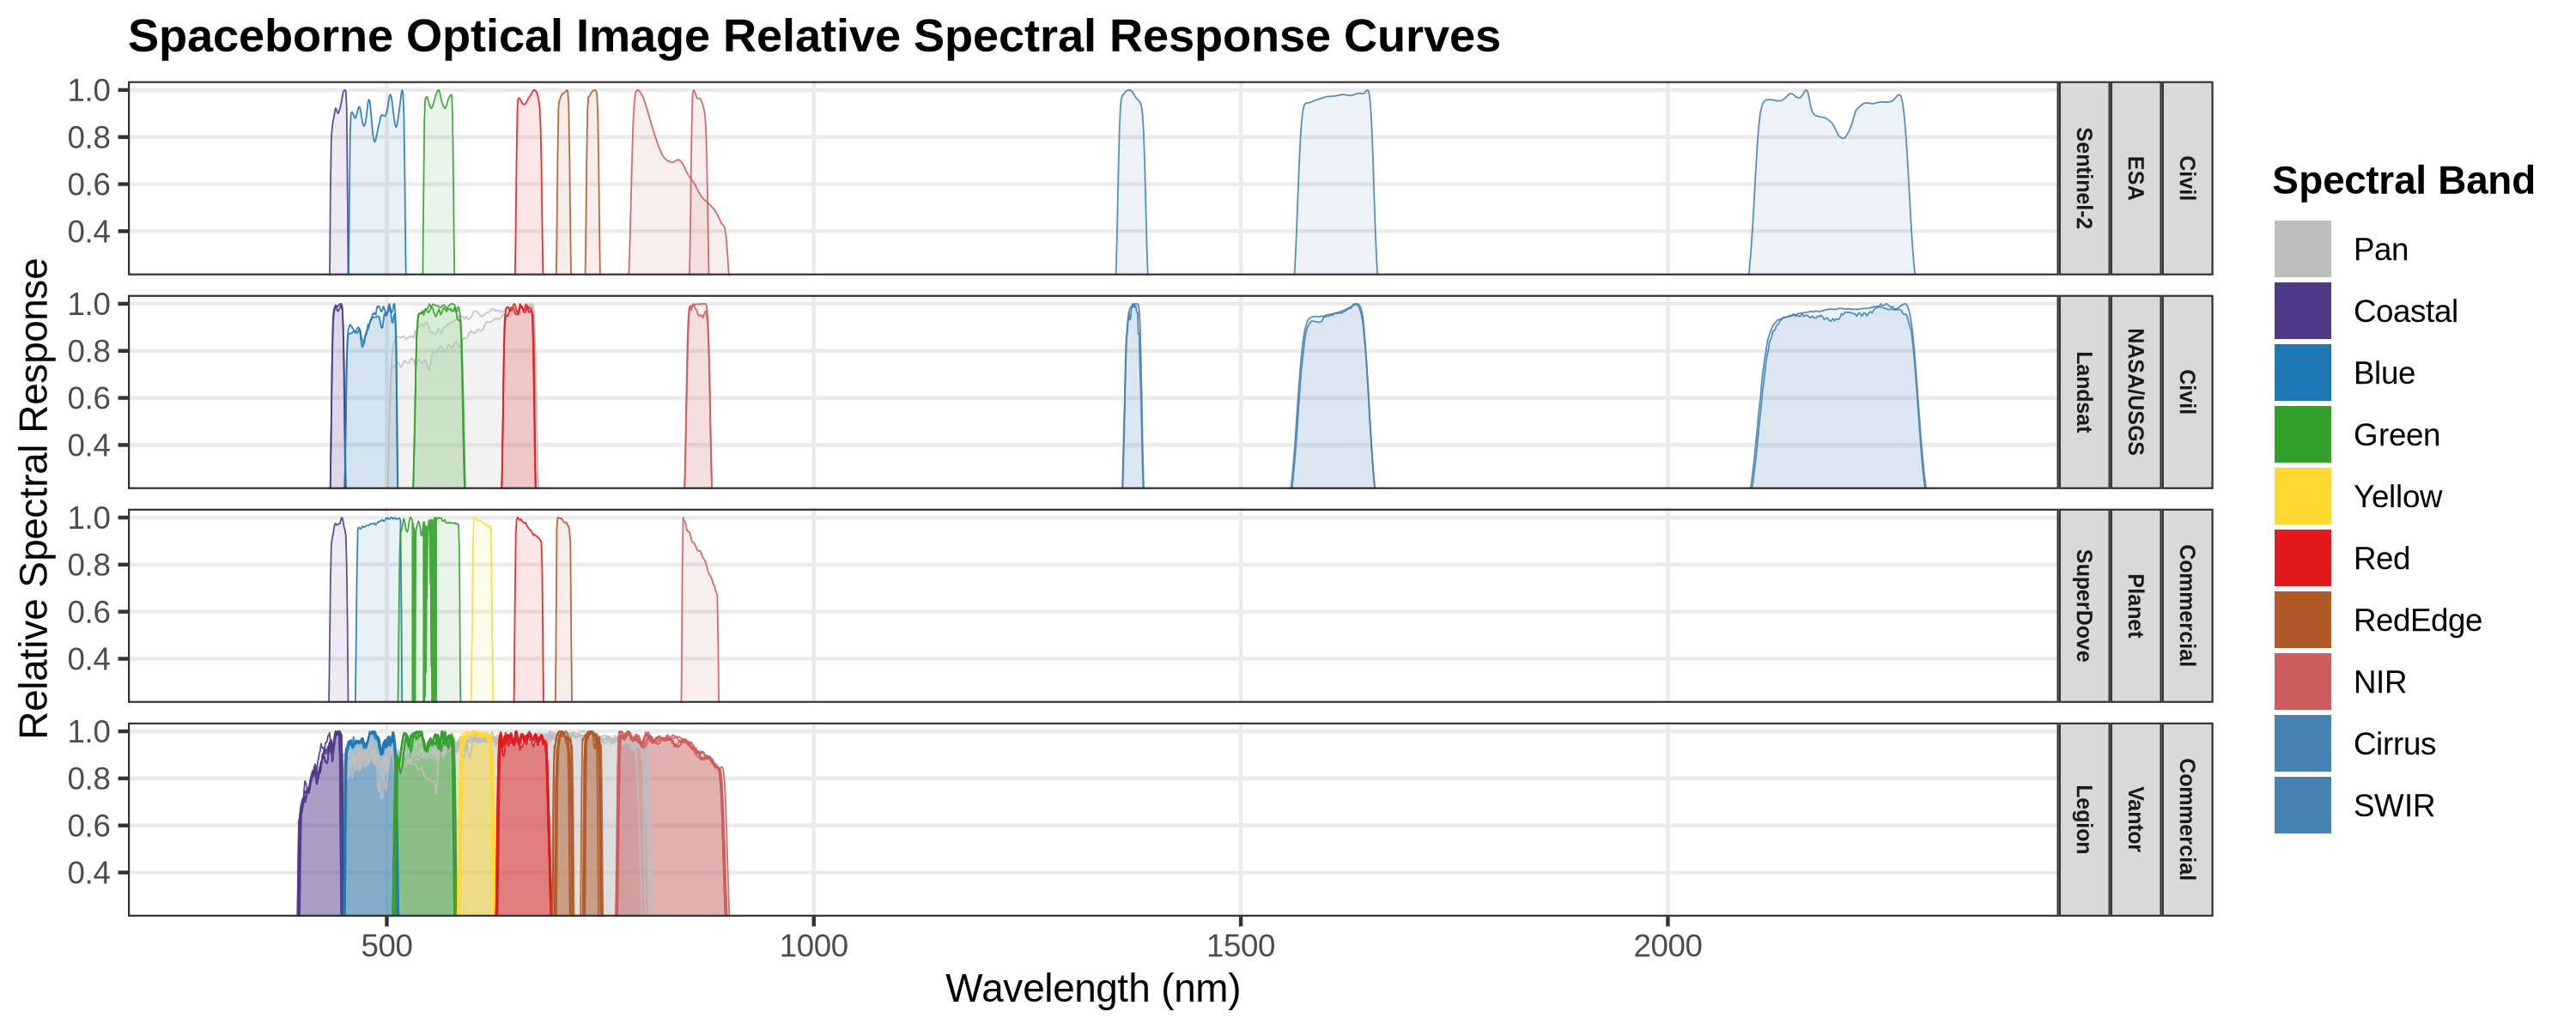

In [21]:
options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(constellation %in% c("Legion", "SuperDove", "Sentinel-2", "Landsat")) %>% filter(!(band %in% c('TIR1','TIR2'))))

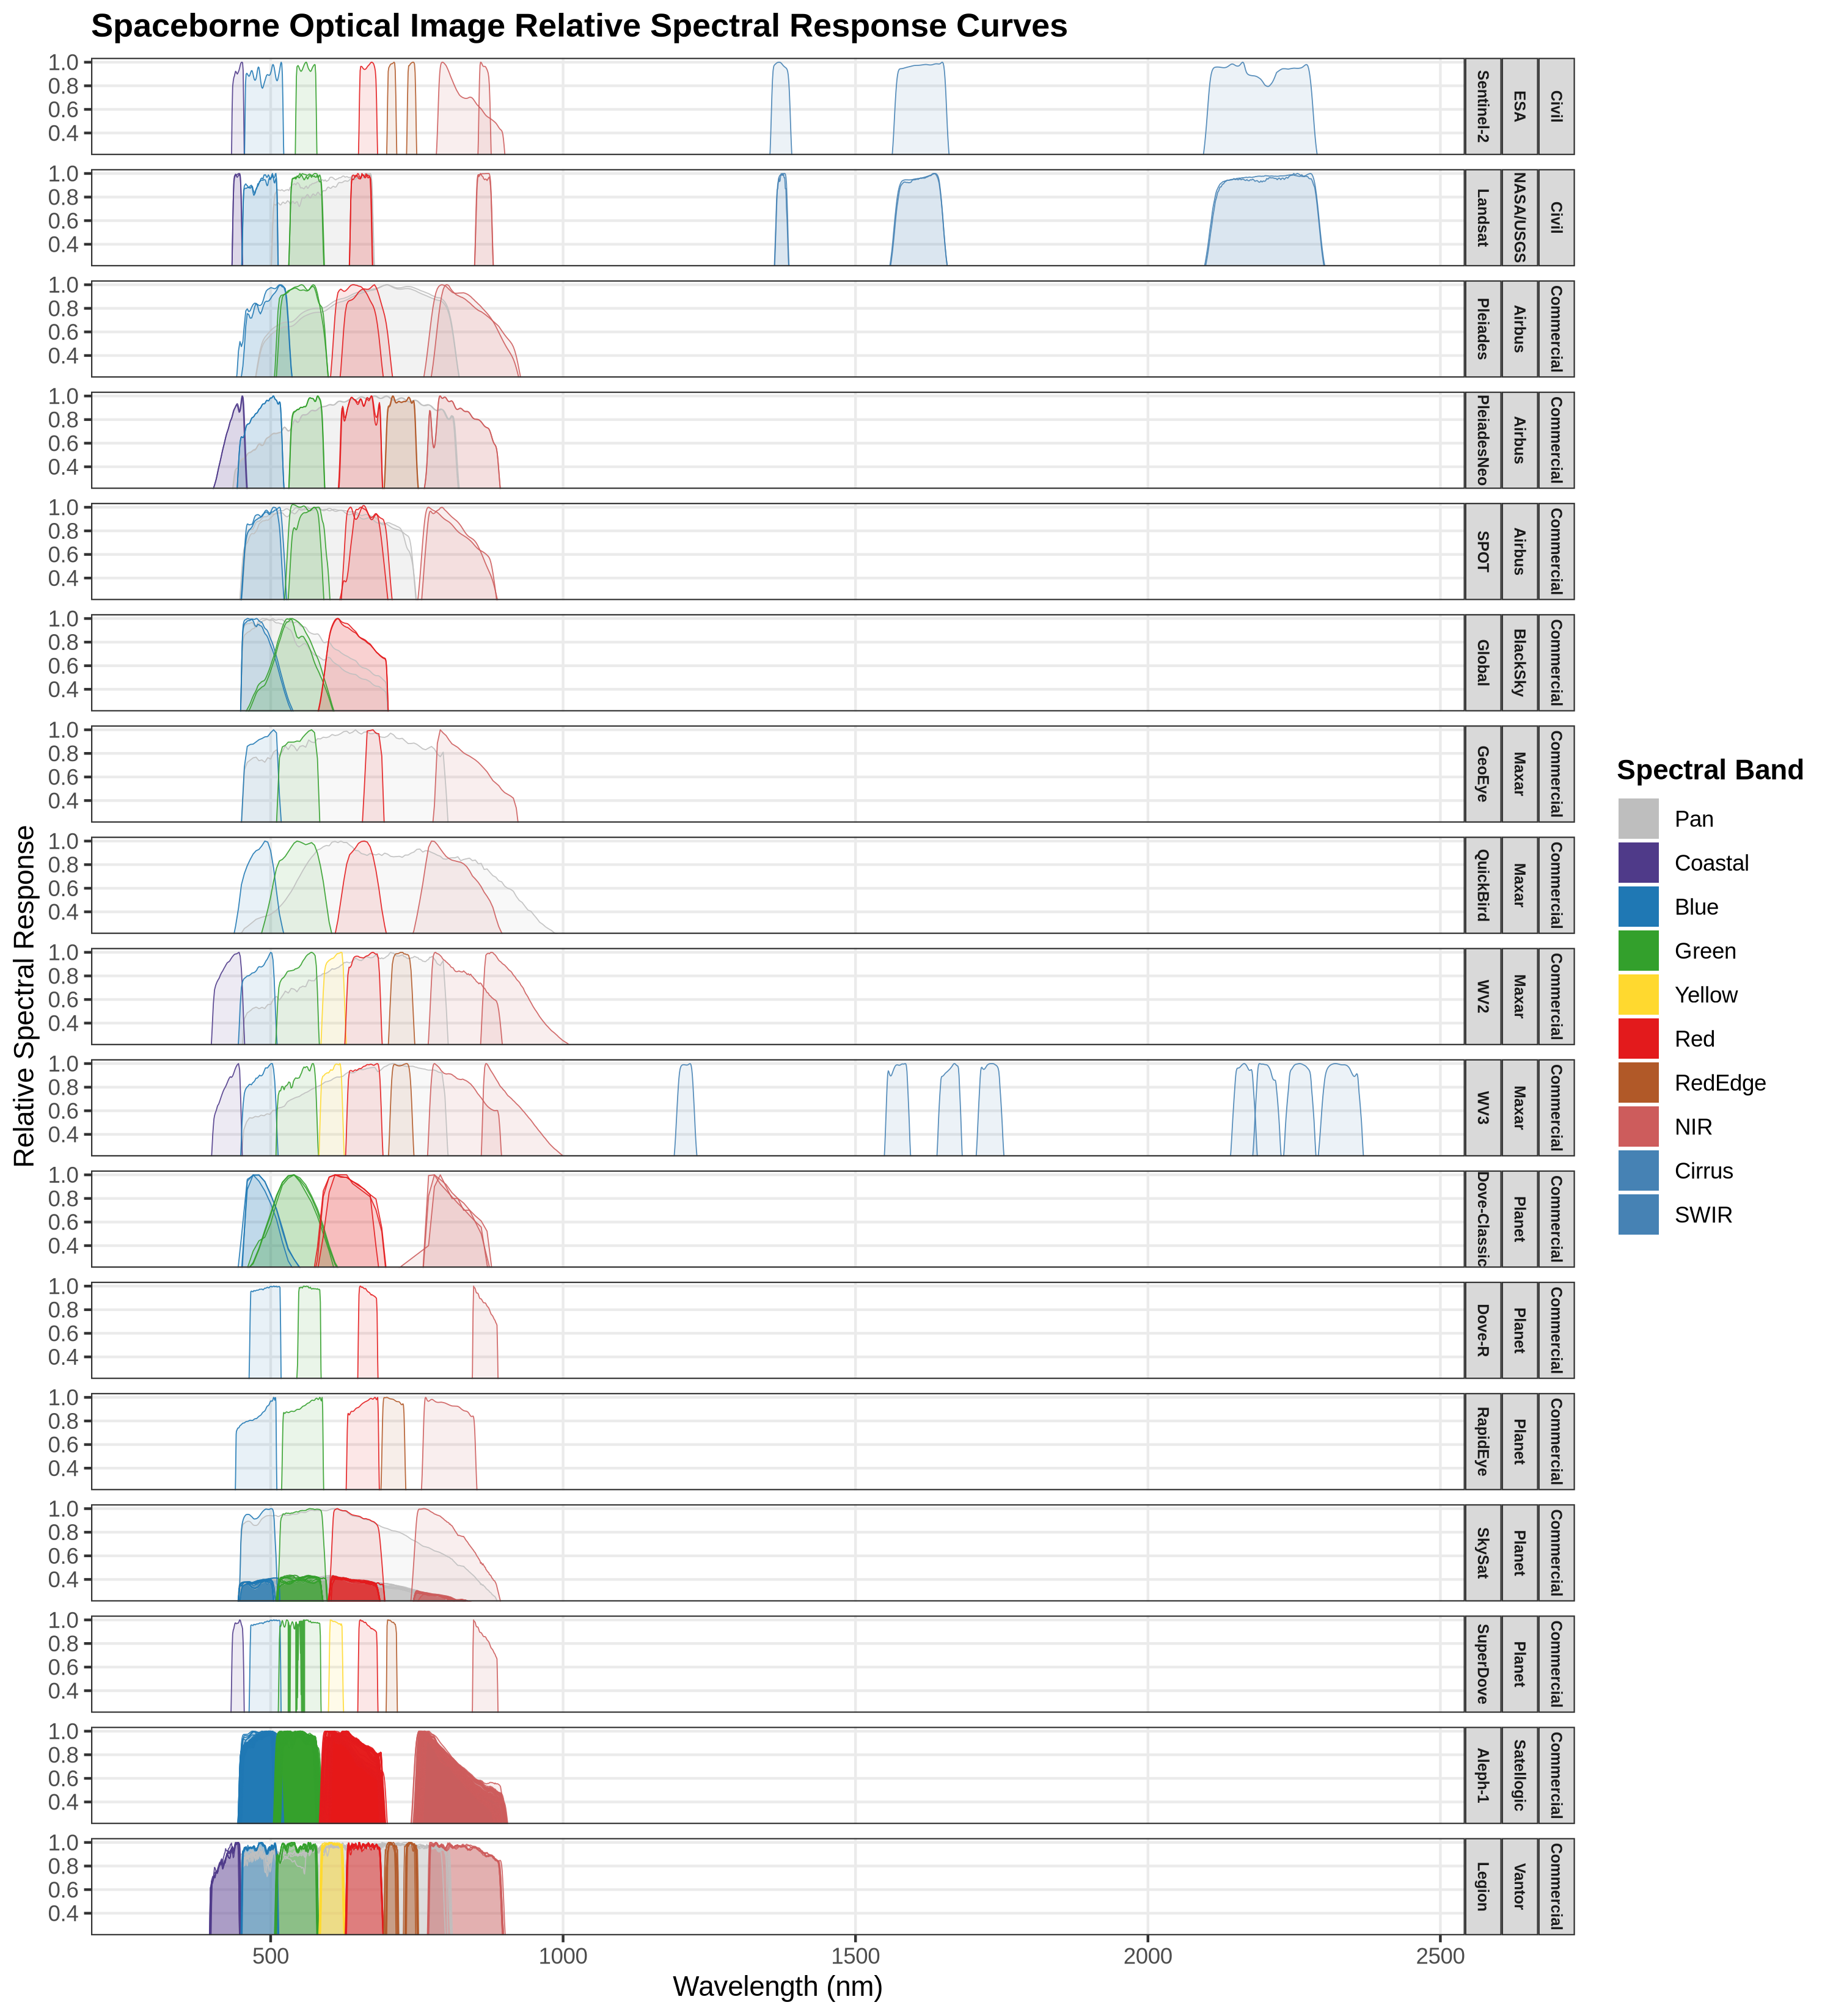

In [22]:
options(repr.plot.width = 10, repr.plot.height = 11, repr.plot.res = 300)

PLOT_RSR_CURVES(df_rsr_combined %>% filter(!(band %in% c('TIR1','TIR2'))))